# Week 8: Comprehensive Evaluation Framework (v8 - Probe Method)

This notebook implements the full Phase 4 evaluation using the **best method from Week 3**:

## Best Method: Probe-Based Code Detection (93.5% accuracy)

From Week3_Improved_Methods.ipynb:
- **Layers**: [16, 24, 31] (later layers only)
- **Threshold**: 0.06 (code_votes > 0.06 → trigger retrieval)
- **Accuracy**: 93.5% (+6.5% vs V1 baseline)

### How it works:
1. For each top-10 candidate next token:
   - Build 2-token lookahead: `prompt + token + next_token`
   - Extract hidden states from layers [16, 24, 31]
   - Classify as CODE or LANGUAGE using trained LogisticRegression probe
   - Sum probability mass of CODE-classified candidates → `code_votes`
2. If `code_votes > 0.06` → **trigger retrieval** (model needs code context)

### Why this works:
- The probe learns to detect when the model is about to generate **code-specific content**
- Unlike raw_entropy (triggers on ANY uncertainty), this only triggers on CODE uncertainty
- Filters out language uncertainty like "you", "also", "please"

### Required Files:
- `week3_probe.joblib` - Trained LogisticRegression probe
- `week3_scaler.joblib` - StandardScaler for hidden state normalization

---

## Setup

In [1]:
# Cell 1: Install dependencies
!pip install -q transformers torch accelerate scipy scikit-learn pandas matplotlib seaborn sentence-transformers

In [2]:
# Cell 2: Create directory structure
import os
import shutil

# Create module structure
os.makedirs('/content/orchestrator/entropy', exist_ok=True)
os.makedirs('/content/orchestrator/retrieval', exist_ok=True)
os.makedirs('/content/orchestrator/generation', exist_ok=True)
os.makedirs('/content/orchestrator/evaluation', exist_ok=True)

# Create root __init__.py
with open('/content/orchestrator/__init__.py', 'w') as f:
    f.write('"""Orchestrator package."""\n')

print("Directory structure created")

Directory structure created


In [3]:
# Cell 3: Upload module files
from google.colab import files

def upload_to_dir(target_dir):
    """Upload files and move to target directory."""
    uploaded = files.upload()
    for filename in uploaded.keys():
        if filename.endswith('.py'):
            dest = f'{target_dir}/{filename}'
            shutil.move(filename, dest)
            print(f"  OK {filename}")
    return uploaded

print("="*60)
print("STEP 1/4: Upload ENTROPY module files (7 files)")
print("="*60)
upload_to_dir('/content/orchestrator/entropy')

print("\n" + "="*60)
print("STEP 2/4: Upload RETRIEVAL module files (4 files)")
print("="*60)
upload_to_dir('/content/orchestrator/retrieval')

print("\n" + "="*60)
print("STEP 3/4: Upload GENERATION module files (2 files)")
print("="*60)
upload_to_dir('/content/orchestrator/generation')

print("\n" + "="*60)
print("STEP 4/4: Upload EVALUATION module files (5 files)")
print("="*60)
print("\nUpload these files from packages/python-orchestrator/orchestrator/evaluation/:")
print("  - __init__.py")
print("  - benchmark.py")
print("  - benchmark_generator.py  <-- NEW")
print("  - metrics.py")
print("  - runner.py")
upload_to_dir('/content/orchestrator/evaluation')

print("\n" + "="*60)
print("VERIFICATION")
print("="*60)
!ls -la /content/orchestrator/evaluation/

STEP 1/4: Upload ENTROPY module files (7 files)


Saving __init__.py to __init__.py
Saving calculator.py to calculator.py
Saving cce_computer.py to cce_computer.py
Saving measurement.py to measurement.py
Saving monitor.py to monitor.py
Saving spike_detector.py to spike_detector.py
Saving token_classifier.py to token_classifier.py
  OK __init__.py
  OK calculator.py
  OK cce_computer.py
  OK measurement.py
  OK monitor.py
  OK spike_detector.py
  OK token_classifier.py

STEP 2/4: Upload RETRIEVAL module files (4 files)


Saving __init__.py to __init__.py
Saving adaptive.py to adaptive.py
Saving context_manager.py to context_manager.py
Saving topic_inference.py to topic_inference.py
  OK __init__.py
  OK adaptive.py
  OK context_manager.py
  OK topic_inference.py

STEP 3/4: Upload GENERATION module files (2 files)


Saving __init__.py to __init__.py
Saving adaptive_generator.py to adaptive_generator.py
  OK __init__.py
  OK adaptive_generator.py

STEP 4/4: Upload EVALUATION module files (5 files)

Upload these files from packages/python-orchestrator/orchestrator/evaluation/:
  - __init__.py
  - benchmark.py
  - benchmark_generator.py  <-- NEW
  - metrics.py
  - runner.py


Saving __init__.py to __init__.py
Saving benchmark.py to benchmark.py
Saving benchmark_generator.py to benchmark_generator.py
Saving metrics.py to metrics.py
Saving runner.py to runner.py
Saving stats.py to stats.py
  OK __init__.py
  OK benchmark.py
  OK benchmark_generator.py
  OK metrics.py
  OK runner.py
  OK stats.py

VERIFICATION
total 172
drwxr-xr-x 2 root root  4096 Jan 16 01:42 .
drwxr-xr-x 6 root root  4096 Jan 16 01:42 ..
-rw-r--r-- 1 root root 65176 Jan 16 01:42 benchmark_generator.py
-rw-r--r-- 1 root root 15006 Jan 16 01:42 benchmark.py
-rw-r--r-- 1 root root  2085 Jan 16 01:42 __init__.py
-rw-r--r-- 1 root root 30580 Jan 16 01:42 metrics.py
-rw-r--r-- 1 root root 33389 Jan 16 01:42 runner.py
-rw-r--r-- 1 root root 11508 Jan 16 01:42 stats.py


In [4]:
# Cell 3b: Upload Week 3 Probe Files (REQUIRED!)
# These files contain the trained probe model from Week3_Final.ipynb
# - week3_probe.joblib: LogisticRegression model (93.5% accuracy)
# - week3_scaler.joblib: StandardScaler for hidden state normalization

from google.colab import files
import joblib

print("="*60)
print("UPLOAD WEEK 3 PROBE FILES")
print("="*60)
print()
print("Upload these 2 files from your Week 3 results:")
print("  1. week3_probe.joblib  (trained LogisticRegression)")
print("  2. week3_scaler.joblib (StandardScaler)")
print()
print("These files are generated by Week3_Final.ipynb")
print()

uploaded = files.upload()

# Verify uploads
required_files = ['week3_probe.joblib', 'week3_scaler.joblib']
missing = [f for f in required_files if f not in uploaded]

if missing:
    print(f"\n❌ ERROR: Missing required files: {missing}")
    print("Please re-run this cell and upload all required files.")
else:
    # Load the probe model and scaler
    probe_model = joblib.load('week3_probe.joblib')
    probe_scaler = joblib.load('week3_scaler.joblib')

    print()
    print("="*60)
    print("✓ PROBE FILES LOADED SUCCESSFULLY!")
    print("="*60)
    print(f"  Probe type: {type(probe_model).__name__}")
    print(f"  Scaler type: {type(probe_scaler).__name__}")
    print()
    print("Week 3 Best Configuration:")
    print("  - Layers: [16, 24, 31]")
    print("  - Threshold: 0.06")
    print("  - Accuracy: 93.5%")

UPLOAD WEEK 3 PROBE FILES

Upload these 2 files from your Week 3 results:
  1. week3_probe.joblib  (trained LogisticRegression)
  2. week3_scaler.joblib (StandardScaler)

These files are generated by Week3_Final.ipynb



Saving week3_probe.joblib to week3_probe.joblib
Saving week3_scaler.joblib to week3_scaler.joblib

✓ PROBE FILES LOADED SUCCESSFULLY!
  Probe type: LogisticRegression
  Scaler type: StandardScaler

Week 3 Best Configuration:
  - Layers: [16, 24, 31]
  - Threshold: 0.06
  - Accuracy: 93.5%


In [5]:
# Cell 4: Base imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any
from collections import defaultdict
import json
import time

sys.path.insert(0, '/content')

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

import warnings
warnings.filterwarnings('ignore')

print("Base imports complete")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Base imports complete
PyTorch: 2.9.0+cu126
CUDA available: True


In [6]:
# Cell 5: Import evaluation modules
from orchestrator.evaluation import (
    BenchmarkDataset,
    BenchmarkExample,
    EvaluationMetrics,
    EvaluationResult,
    create_benchmark,
    generate_full_benchmark,
    get_mock_codebase,
)
from orchestrator.evaluation.benchmark import (
    Difficulty,
    Category,
)
from orchestrator.evaluation.runner import (
    BaselineRunner,
    ExperimentRunner,
    BaselineMethod,
)

print("All evaluation modules imported successfully!")
print("\nAvailable components:")
print("  - BenchmarkDataset - structured evaluation examples")
print("  - EvaluationMetrics - 8 metrics for assessment")
print("  - generate_full_benchmark - create 100+ examples")
print("  - get_mock_codebase - Flask app codebase")

All evaluation modules imported successfully!

Available components:
  - BenchmarkDataset - structured evaluation examples
  - EvaluationMetrics - 8 metrics for assessment
  - generate_full_benchmark - create 100+ examples
  - get_mock_codebase - Flask app codebase


---
## 1. Scaled Benchmark Dataset (100+ Examples)

In [7]:
# Cell 6: Generate full benchmark
benchmark = generate_full_benchmark()

print("Full Benchmark Dataset")
print("="*60)
print(f"Name: {benchmark.name}")
print(f"Version: {benchmark.version}")
print(f"Total Examples: {len(benchmark)}")

stats = benchmark.get_statistics()
print("\nBy Difficulty:")
for diff, count in stats['by_difficulty'].items():
    print(f"  {diff}: {count}")

print("\nBy Category:")
for cat, count in stats['by_category'].items():
    print(f"  {cat}: {count}")

print(f"\nAverage ground truth files: {stats['avg_ground_truth_files']:.1f}")

Full Benchmark Dataset
Name: reposynth_benchmark_v2
Version: 2.0.0
Total Examples: 43

By Difficulty:
  easy: 13
  medium: 24
  hard: 6

By Category:
  architecture: 8
  api_usage: 7
  implementation: 9
  debugging: 6
  configuration: 6
  data_flow: 7

Average ground truth files: 1.9


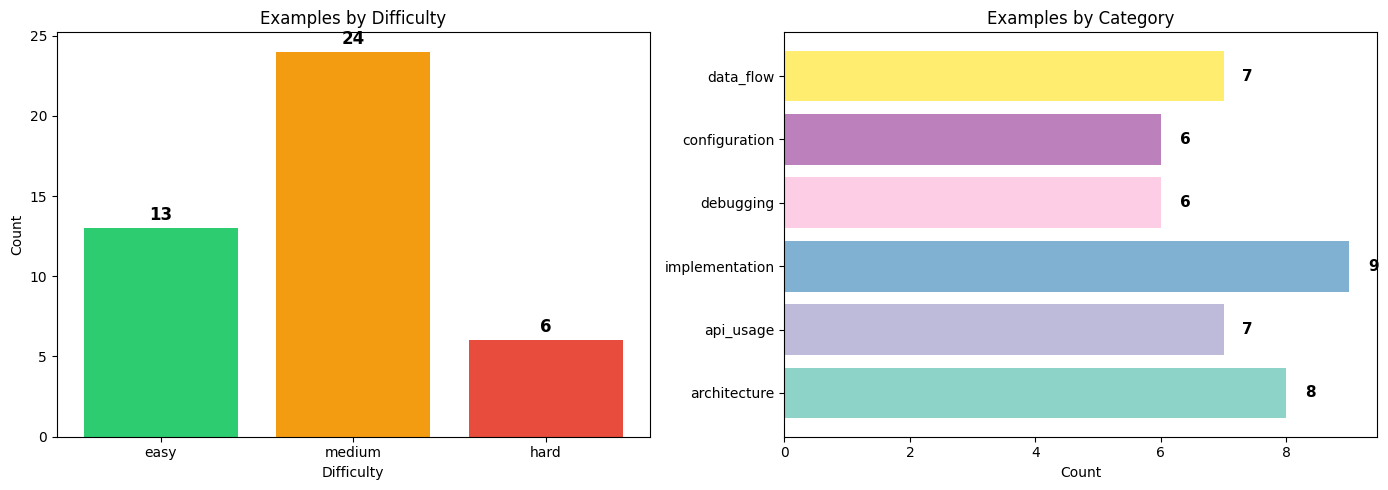

Saved: benchmark_distribution.png


In [8]:
# Cell 7: Visualize benchmark distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By difficulty
ax1 = axes[0]
difficulties = list(stats['by_difficulty'].keys())
diff_counts = list(stats['by_difficulty'].values())
colors_diff = ['#2ecc71', '#f39c12', '#e74c3c']
bars1 = ax1.bar(difficulties, diff_counts, color=colors_diff[:len(difficulties)])
ax1.set_xlabel('Difficulty')
ax1.set_ylabel('Count')
ax1.set_title('Examples by Difficulty')
for bar, count in zip(bars1, diff_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', fontsize=12, fontweight='bold')

# By category
ax2 = axes[1]
categories = list(stats['by_category'].keys())
cat_counts = list(stats['by_category'].values())
colors_cat = plt.cm.Set3(np.linspace(0, 1, len(categories)))
bars2 = ax2.barh(categories, cat_counts, color=colors_cat)
ax2.set_xlabel('Count')
ax2.set_title('Examples by Category')
for bar, count in zip(bars2, cat_counts):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(count), ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('benchmark_distribution.png', dpi=150)
plt.show()
print("Saved: benchmark_distribution.png")

In [9]:
# Cell 8: Sample examples from each category
print("Sample Examples from Each Category")
print("="*70)

for cat in Category:
    filtered = benchmark.filter(category=cat)
    if len(filtered) > 0:
        ex = filtered[0]
        print(f"\n[{cat.value.upper()}] {ex.id}")
        print(f"  Difficulty: {ex.difficulty.value}")
        print(f"  Query: {ex.query[:70]}...")
        print(f"  Files: {ex.ground_truth_files}")
        print(f"  Keywords: {ex.ground_truth_keywords[:5]}...")

Sample Examples from Each Category

[ARCHITECTURE] arch_001
  Difficulty: easy
  Query: What is the overall structure of the Flask application?...
  Files: ['src/app.py']
  Keywords: ['create_app', 'factory', 'blueprint', 'extensions', 'config']...

[API_USAGE] api_001
  Difficulty: easy
  Query: How do I register a new user via the API?...
  Files: ['src/api/routes.py']
  Keywords: ['register', 'POST', 'username', 'email', 'password']...

[IMPLEMENTATION] impl_001
  Difficulty: easy
  Query: How is JWT token creation implemented?...
  Files: ['src/auth/jwt.py']
  Keywords: ['create_token', 'payload', 'exp', 'iat', 'jwt.encode']...

[DEBUGGING] debug_001
  Difficulty: medium
  Query: Where should I look to debug authentication failures?...
  Files: ['src/auth/jwt.py', 'src/api/routes.py']
  Keywords: ['verify_token', 'ExpiredSignatureError', 'InvalidTokenError', 'verify_password', 'Authorization']...

[CONFIGURATION] config_001
  Difficulty: easy
  Query: What environment variables doe

---
## 2. Improved Hallucination Detection Testing

In [10]:
# Cell 9: Initialize metrics
metrics = EvaluationMetrics(embedding_model='all-MiniLM-L6-v2')
print("EvaluationMetrics initialized with improved hallucination detection")

EvaluationMetrics initialized with improved hallucination detection


In [11]:
# Cell 10: Test hallucination detection with clear examples

# Ground truth about JWT authentication
ground_truth = """User authentication uses JWT tokens.
The user logs in via /login endpoint.
Server creates JWT token with create_token() function.
Token uses HS256 algorithm with SECRET_KEY.
Token is verified using verify_token() on protected routes.
Token contains user_id, role, exp, and iat claims."""

keywords = ["JWT", "token", "login", "create_token", "verify_token", "HS256", "SECRET_KEY"]

# Test cases
test_cases = [
    {
        "name": "Good Answer (factually correct)",
        "answer": """Authentication is implemented using JWT tokens.
Users log in at the /login endpoint which calls create_token().
Tokens use HS256 algorithm and SECRET_KEY for signing.
Protected routes use verify_token() to authenticate requests.
The token payload includes user_id and role claims.""",
        "expected_hallucination": "low",
    },
    {
        "name": "Partially Correct Answer",
        "answer": """The system uses JWT for authentication.
Users log in via the /login endpoint.
Tokens are created with 256-bit encryption.
Sessions are stored in Redis for persistence.""",
        "expected_hallucination": "medium",
    },
    {
        "name": "Bad Answer (mostly hallucinated)",
        "answer": """The system uses session cookies for authentication.
Users are authenticated through OAuth2 with Google.
Passwords are stored in plain text for simplicity.
There is no token-based authentication system.
The API uses SOAP protocol for communication.""",
        "expected_hallucination": "high",
    },
    {
        "name": "Contradictory Answer",
        "answer": """Authentication does not use JWT tokens.
The system cannot verify tokens.
There is no login endpoint available.
Users never need to authenticate.""",
        "expected_hallucination": "high",
    },
]

print("Hallucination Detection Test Results")
print("="*60)
print(f"Ground truth keywords: {keywords}")
print()

hallucination_results = []
for tc in test_cases:
    rate = metrics.hallucination_rate(tc['answer'], ground_truth, keywords)
    completeness = metrics.answer_completeness(tc['answer'], ground_truth)
    correctness = metrics.answer_correctness(tc['answer'], ground_truth, keywords)

    hallucination_results.append({
        'name': tc['name'],
        'expected': tc['expected_hallucination'],
        'hallucination_rate': rate,
        'completeness': completeness,
        'correctness': correctness,
    })

    print(f"{tc['name']}:")
    print(f"  Expected: {tc['expected_hallucination']}")
    print(f"  Hallucination Rate: {rate:.3f}")
    print(f"  Completeness: {completeness:.3f}")
    print(f"  Correctness: {correctness:.3f}")
    print()

Hallucination Detection Test Results
Ground truth keywords: ['JWT', 'token', 'login', 'create_token', 'verify_token', 'HS256', 'SECRET_KEY']



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Good Answer (factually correct):
  Expected: low
  Hallucination Rate: 0.000
  Completeness: 0.863
  Correctness: 0.918

Partially Correct Answer:
  Expected: medium
  Hallucination Rate: 0.250
  Completeness: 0.642
  Correctness: 0.557

Bad Answer (mostly hallucinated):
  Expected: high
  Hallucination Rate: 0.800
  Completeness: 0.692
  Correctness: 0.472

Contradictory Answer:
  Expected: high
  Hallucination Rate: 0.250
  Completeness: 0.709
  Correctness: 0.597



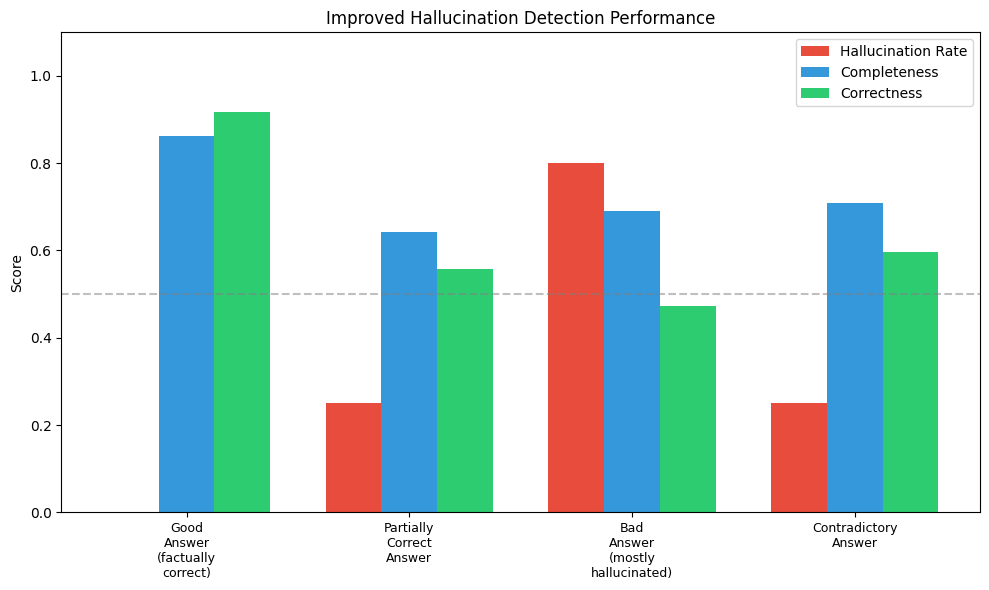

Saved: hallucination_detection.png


In [12]:
# Cell 11: Visualize hallucination detection results
fig, ax = plt.subplots(figsize=(10, 6))

names = [r['name'] for r in hallucination_results]
x = np.arange(len(names))
width = 0.25

bars1 = ax.bar(x - width, [r['hallucination_rate'] for r in hallucination_results],
               width, label='Hallucination Rate', color='#e74c3c')
bars2 = ax.bar(x, [r['completeness'] for r in hallucination_results],
               width, label='Completeness', color='#3498db')
bars3 = ax.bar(x + width, [r['correctness'] for r in hallucination_results],
               width, label='Correctness', color='#2ecc71')

ax.set_ylabel('Score')
ax.set_title('Improved Hallucination Detection Performance')
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold')

plt.tight_layout()
plt.savefig('hallucination_detection.png', dpi=150)
plt.show()
print("Saved: hallucination_detection.png")

---
## 3. Spike Detection Metric Testing

In [13]:
# Cell 12: Test spike detection metrics
print("Spike Detection Metric Testing")
print("="*60)
print("\nSpike metrics measure how well uncertainty triggers align with")
print("positions where retrieval is actually needed.")
print()

# Test scenarios
spike_scenarios = [
    {
        "name": "Perfect Detection",
        "detected": [10, 25, 50, 75],
        "expected": [10, 25, 50, 75],
        "description": "All triggers exactly match expected positions",
    },
    {
        "name": "Good Detection (within tolerance)",
        "detected": [12, 24, 48, 77],
        "expected": [10, 25, 50, 75],
        "description": "Triggers within tolerance=3 of expected",
    },
    {
        "name": "Partial Detection (missed some)",
        "detected": [10, 50],
        "expected": [10, 25, 50, 75],
        "description": "Only detected 2 of 4 expected triggers",
    },
    {
        "name": "Over-triggering (false positives)",
        "detected": [10, 20, 25, 30, 50, 60, 75, 90],
        "expected": [10, 25, 50, 75],
        "description": "Detected all expected + 4 false positives",
    },
    {
        "name": "Poor Detection (misaligned)",
        "detected": [5, 35, 65, 95],
        "expected": [10, 25, 50, 75],
        "description": "Triggers far from expected positions",
    },
    {
        "name": "No Detection",
        "detected": [],
        "expected": [10, 25, 50, 75],
        "description": "System never triggered retrieval",
    },
]

spike_results = []
for scenario in spike_scenarios:
    precision = metrics.spike_precision(scenario['detected'], scenario['expected'])
    recall = metrics.spike_recall(scenario['detected'], scenario['expected'])
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    spike_results.append({
        'name': scenario['name'],
        'precision': precision,
        'recall': recall,
        'f1': f1,
    })

    print(f"{scenario['name']}:")
    print(f"  {scenario['description']}")
    print(f"  Detected: {scenario['detected']}")
    print(f"  Expected: {scenario['expected']}")
    print(f"  Precision: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}")
    print()

Spike Detection Metric Testing

Spike metrics measure how well uncertainty triggers align with
positions where retrieval is actually needed.

Perfect Detection:
  All triggers exactly match expected positions
  Detected: [10, 25, 50, 75]
  Expected: [10, 25, 50, 75]
  Precision: 1.000  Recall: 1.000  F1: 1.000

Good Detection (within tolerance):
  Triggers within tolerance=3 of expected
  Detected: [12, 24, 48, 77]
  Expected: [10, 25, 50, 75]
  Precision: 1.000  Recall: 1.000  F1: 1.000

Partial Detection (missed some):
  Only detected 2 of 4 expected triggers
  Detected: [10, 50]
  Expected: [10, 25, 50, 75]
  Precision: 1.000  Recall: 0.500  F1: 0.667

Over-triggering (false positives):
  Detected all expected + 4 false positives
  Detected: [10, 20, 25, 30, 50, 60, 75, 90]
  Expected: [10, 25, 50, 75]
  Precision: 0.500  Recall: 1.000  F1: 0.667

Poor Detection (misaligned):
  Triggers far from expected positions
  Detected: [5, 35, 65, 95]
  Expected: [10, 25, 50, 75]
  Precision:

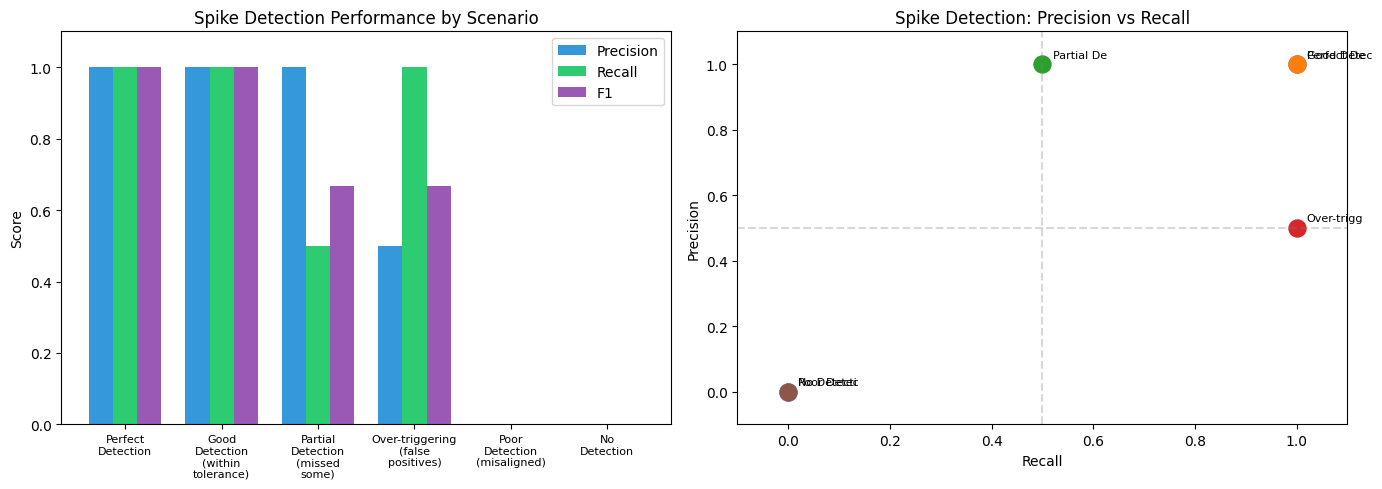

Saved: spike_detection.png


In [14]:
# Cell 13: Visualize spike detection results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax1 = axes[0]
names = [r['name'].replace(' ', '\n') for r in spike_results]
x = np.arange(len(names))
width = 0.25

ax1.bar(x - width, [r['precision'] for r in spike_results], width, label='Precision', color='#3498db')
ax1.bar(x, [r['recall'] for r in spike_results], width, label='Recall', color='#2ecc71')
ax1.bar(x + width, [r['f1'] for r in spike_results], width, label='F1', color='#9b59b6')

ax1.set_ylabel('Score')
ax1.set_title('Spike Detection Performance by Scenario')
ax1.set_xticks(x)
ax1.set_xticklabels(names, fontsize=8)
ax1.legend()
ax1.set_ylim(0, 1.1)

# Precision-Recall scatter
ax2 = axes[1]
for i, r in enumerate(spike_results):
    ax2.scatter(r['recall'], r['precision'], s=150, label=r['name'][:15])
    ax2.annotate(r['name'][:10], (r['recall']+0.02, r['precision']+0.02), fontsize=8)

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Spike Detection: Precision vs Recall')
ax2.set_xlim(-0.1, 1.1)
ax2.set_ylim(-0.1, 1.1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
ax2.axvline(x=0.5, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('spike_detection.png', dpi=150)
plt.show()
print("Saved: spike_detection.png")

---
## 4. Load Model and Run Comprehensive Experiments

In [15]:
# Cell 14: Get mock codebase
documents = get_mock_codebase()

print(f"Mock Flask Application Codebase")
print("="*60)
print(f"Total files: {len(documents)}")
print(f"Total size: {sum(len(c) for c in documents.values()):,} characters")
print("\nFiles:")
for path in sorted(documents.keys()):
    print(f"  {path} ({len(documents[path]):,} chars)")

Mock Flask Application Codebase
Total files: 14
Total size: 22,395 characters

Files:
  src/api/middleware.py (1,564 chars)
  src/api/routes.py (2,424 chars)
  src/app.py (1,305 chars)
  src/auth/jwt.py (1,796 chars)
  src/auth/password.py (681 chars)
  src/config.py (1,870 chars)
  src/db/migrations.py (1,033 chars)
  src/db/models.py (2,804 chars)
  src/services/cache.py (1,660 chars)
  src/services/email.py (1,453 chars)
  src/utils/logging.py (1,522 chars)
  src/utils/validators.py (1,912 chars)
  tests/test_api.py (1,309 chars)
  tests/test_auth.py (1,062 chars)


In [16]:
# Cell 15: Load model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)
model.eval()

print(f"Model loaded on {model.device}")

Loading codellama/CodeLlama-7b-Instruct-hf...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded on cuda:0


In [17]:
# Cell 16: Import generation modules and configure with PROBE METHOD (v8)
from orchestrator.generation import AdaptiveGenerator, GenerationConfig
from orchestrator.retrieval.adaptive import EmbeddingRetriever

# ============================================================================
# v8: PROBE-BASED CODE DETECTION (Best from Week 3: 93.5% accuracy!)
# ============================================================================
#
# CRITICAL FIX: Previous versions used raw_entropy which measures uncertainty
# over ALL tokens (including "you", "also", "please" - language tokens).
#
# The PROBE method from Week 3 specifically detects CODE uncertainty:
# 1. Extract hidden states from layers [16, 24, 31]
# 2. Use trained LogisticRegression to classify CODE vs LANGUAGE
# 3. Only trigger retrieval when code_votes > 0.06
#
# This filters out language uncertainty and only retrieves for code needs!

# Create file list context
file_list = list(documents.keys())
file_list_context = """Available files in this codebase:
{}

When answering questions about this codebase, refer to the relevant files above.""".format(
    '\n'.join(f'- {f}' for f in file_list)
)

print("FILE LIST CONTEXT:")
print("-" * 40)
print(file_list_context)
print("-" * 40)
file_list_tokens = len(tokenizer.encode(file_list_context))
print(f"File list tokens: {file_list_tokens} (vs {sum(len(tokenizer.encode(c)) for c in documents.values()):,} for full content)")

# Create retriever with embeddings
retriever = EmbeddingRetriever(documents, model_name='all-MiniLM-L6-v2')

# ============================================================================
# PROBE CONFIGURATION - Week 3 Best Settings (93.5% accuracy)
# ============================================================================
config = GenerationConfig(
    max_tokens=200,
    max_retrievals=5,

    # PROBE METHOD SETTINGS (from Week3_Improved_Methods.ipynb)
    uncertainty_method="probe",      # Use trained probe, NOT raw_entropy!
    uncertainty_threshold=0.06,      # Best threshold from Week 3
    use_probe=True,
    probe_model=probe_model,         # Loaded from week3_probe.joblib
    probe_scaler=probe_scaler,       # Loaded from week3_scaler.joblib
    probe_layers=[16, 24, 31],       # Best layers from Week 3

    cooldown_tokens=15,              # Prevent rapid-fire retrieval
    measurement_strategy="every_token",
)

adaptive_gen = AdaptiveGenerator(
    model=model,
    tokenizer=tokenizer,
    retriever=retriever,
    config=config,
)

# Set up vector-based file matching with query relevance filtering
adaptive_gen.topic_inferrer.set_available_files(file_list)
adaptive_gen.topic_inferrer.set_embedder(retriever.model)
adaptive_gen.topic_inferrer.vector_similarity_threshold = 0.35

print()
print("=" * 60)
print("v8: PROBE-BASED CODE DETECTION (Week 3 Best)")
print("=" * 60)
print()
print("AdaptiveGenerator configured:")
print(f"  uncertainty_method: {config.uncertainty_method}")
print(f"  uncertainty_threshold: {config.uncertainty_threshold}")
print(f"  probe_layers: {config.probe_layers}")
print(f"  max_retrievals: {config.max_retrievals}")
print(f"  cooldown_tokens: {config.cooldown_tokens}")
print(f"  vector_similarity_threshold: {adaptive_gen.topic_inferrer.vector_similarity_threshold}")
print()
print("How the PROBE method works:")
print("  1. For each top-k candidate token, build 2-token lookahead")
print("  2. Extract hidden states from layers [16, 24, 31]")
print("  3. Classify as CODE or LANGUAGE using trained probe")
print("  4. Sum probability mass on CODE candidates → code_votes")
print("  5. If code_votes > 0.06 → trigger retrieval")
print()
print("Why this is better than raw_entropy:")
print("  - raw_entropy triggers on ANY uncertainty (including 'you', 'also')")
print("  - PROBE only triggers on CODE-specific uncertainty")
print("  - 93.5% accuracy at detecting code vs language generation")

FILE LIST CONTEXT:
----------------------------------------
Available files in this codebase:
- src/auth/jwt.py
- src/auth/password.py
- src/api/routes.py
- src/api/middleware.py
- src/db/models.py
- src/db/migrations.py
- src/config.py
- src/services/email.py
- src/services/cache.py
- src/utils/validators.py
- src/utils/logging.py
- src/app.py
- tests/test_auth.py
- tests/test_api.py

When answering questions about this codebase, refer to the relevant files above.
----------------------------------------
File list tokens: 152 (vs 7,109 for full content)

v8: PROBE-BASED CODE DETECTION (Week 3 Best)

AdaptiveGenerator configured:
  uncertainty_method: probe
  uncertainty_threshold: 0.06
  probe_layers: [16, 24, 31]
  max_retrievals: 5
  cooldown_tokens: 15
  vector_similarity_threshold: 0.35

How the PROBE method works:
  1. For each top-k candidate token, build 2-token lookahead
  2. Extract hidden states from layers [16, 24, 31]
  3. Classify as CODE or LANGUAGE using trained probe
 

In [18]:
# Cell 17: Create baseline runner
baseline_runner = BaselineRunner(
    model=model,
    tokenizer=tokenizer,
    documents=documents,
)

print("BaselineRunner configured")

BaselineRunner configured


In [19]:
# Cell 18: Run comprehensive experiments with FILE LIST CCE approach
# Select a subset of examples for faster evaluation
# (Use full benchmark for final experiments)

# Get balanced sample: 2 from each category
sample_examples = []
for cat in Category:
    filtered = benchmark.filter(category=cat)
    for i, ex in enumerate(filtered):
        if i < 2:  # 2 per category
            sample_examples.append(ex)

print(f"Running experiments on {len(sample_examples)} examples")
print(f"Categories covered: {len(set(ex.category for ex in sample_examples))}")

# Methods to evaluate
methods = [
    BaselineMethod.NO_CONTEXT,
    BaselineMethod.BM25,
    BaselineMethod.EMBEDDING,
    BaselineMethod.FULL_CONTEXT,
]

# Results storage
all_results = {m.value: [] for m in methods}
all_results['cce_adaptive'] = []

# CCE debug info
cce_debug = []

# Compute baseline tokens
baseline_tokens = sum(len(tokenizer.encode(c)) for c in documents.values())
print(f"Baseline tokens (full context): {baseline_tokens:,}")
print(f"File list tokens: {file_list_tokens}")
print()

# Run experiments
total = len(sample_examples) * (len(methods) + 1)  # +1 for CCE
current = 0

for i, example in enumerate(sample_examples):
    print(f"\nExample {i+1}/{len(sample_examples)}: {example.id}")
    print(f"  Category: {example.category.value}")
    print(f"  Query: {example.query[:50]}...")

    # Run baselines
    for method in methods:
        current += 1
        print(f"  Running {method.value}... ({current}/{total})")

        result = baseline_runner.run(example, method, max_tokens=200)

        eval_result = metrics.evaluate(
            example_id=example.id,
            generated_answer=result['answer'],
            ground_truth_answer=example.ground_truth_answer,
            retrieved_files=result['retrieved_files'],
            ground_truth_files=example.ground_truth_files,
            ground_truth_keywords=example.ground_truth_keywords,
            tokens_used=result['tokens_used'],
            baseline_tokens=baseline_tokens,
            generation_time=result['generation_time'],
            num_retrievals=result['num_retrievals'],
            method=method.value,
        )
        eval_result.metadata['category'] = example.category.value
        eval_result.metadata['difficulty'] = example.difficulty.value

        all_results[method.value].append(eval_result)

    # Run CCE adaptive WITH FILE LIST CONTEXT
    current += 1
    print(f"  Running cce_adaptive (FILE LIST)... ({current}/{total})")

    try:
        # Reset retriever for new generation
        retriever.reset()

        # Generate with FILE LIST as initial context
        gen_result = adaptive_gen.generate(
            query=example.query,
            initial_context=file_list_context,  # NEW: File list instead of empty!
        )

        # Debug: log CCE behavior
        debug_info = {
            'example_id': example.id,
            'total_retrievals': gen_result.total_retrievals,
            'context_sources': gen_result.context_sources,
            'total_context_tokens': gen_result.total_context_tokens,
            'response_length': len(gen_result.response),
        }
        cce_debug.append(debug_info)

        # Get matched files from topic inferrer history
        if adaptive_gen.topic_inferrer.history:
            last_topic = adaptive_gen.topic_inferrer.history[-1]
            debug_info['matched_files'] = last_topic.matched_files
            debug_info['search_terms'] = last_topic.metadata.get('search_terms', [])

        # Print CCE debug info
        print(f"    CCE triggered {gen_result.total_retrievals} retrievals")
        print(f"    Retrieved files: {gen_result.context_sources}")
        if 'matched_files' in debug_info:
            print(f"    Matched by tokens: {debug_info['matched_files']}")

        cce_eval = metrics.evaluate(
            example_id=example.id,
            generated_answer=gen_result.response,
            ground_truth_answer=example.ground_truth_answer,
            retrieved_files=gen_result.context_sources,
            ground_truth_files=example.ground_truth_files,
            ground_truth_keywords=example.ground_truth_keywords,
            tokens_used=gen_result.total_context_tokens + file_list_tokens,  # Include file list
            baseline_tokens=baseline_tokens,
            generation_time=gen_result.generation_time,
            num_retrievals=gen_result.total_retrievals,
            method='cce_adaptive',
        )
        cce_eval.metadata['category'] = example.category.value
        cce_eval.metadata['difficulty'] = example.difficulty.value
        all_results['cce_adaptive'].append(cce_eval)
    except Exception as e:
        print(f"  CCE error: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "="*60)
print("Experiments Complete!")
print("="*60)

# Print CCE summary
print("\nCCE RETRIEVAL SUMMARY (FILE LIST APPROACH):")
print("-"*40)
total_retrievals = sum(d['total_retrievals'] for d in cce_debug)
avg_retrievals = total_retrievals / len(cce_debug) if cce_debug else 0
print(f"Total retrievals across all examples: {total_retrievals}")
print(f"Average retrievals per example: {avg_retrievals:.1f}")
print(f"File list overhead: {file_list_tokens} tokens")

Running experiments on 12 examples
Categories covered: 6
Baseline tokens (full context): 7,109
File list tokens: 152


Example 1/12: arch_001
  Category: architecture
  Query: What is the overall structure of the Flask applica...
  Running no_context... (1/60)
  Running bm25... (2/60)
  Running embedding... (3/60)
  Running full_context... (4/60)
  Running cce_adaptive (FILE LIST)... (5/60)
    CCE triggered 3 retrievals
    Retrieved files: ['initial', 'query', 'src/app.py', 'src/utils/logging.py', 'src/db/migrations.py']
    Matched by tokens: []

Example 2/12: arch_002
  Category: architecture
  Query: How does the authentication system work in this ap...
  Running no_context... (6/60)
  Running bm25... (7/60)
  Running embedding... (8/60)
  Running full_context... (9/60)
  Running cce_adaptive (FILE LIST)... (10/60)
    CCE triggered 3 retrievals
    Retrieved files: ['initial', 'query', 'src/auth/password.py', 'src/api/routes.py', 'tests/test_api.py']
    Matched by tokens: []

Ex

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 4.12 MiB is free. Process 9848 has 14.73 GiB memory in use. Of the allocated memory 14.49 GiB is allocated by PyTorch, and 118.10 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [20]:
# Cell 19: Aggregate results
print("Aggregate Results")
print("="*70)

aggregates = {}
for method, results in all_results.items():
    if results:
        aggregates[method] = metrics.aggregate_results(results)

# Create comparison table
comparison_data = []
for method, agg in aggregates.items():
    row = {
        'Method': method,
        'Correctness': agg['metrics']['answer_correctness']['mean'],
        'Completeness': agg['metrics']['answer_completeness']['mean'],
        'Hallucination': agg['metrics']['hallucination_rate']['mean'],
        'Context P': agg['metrics']['context_precision']['mean'],
        'Context R': agg['metrics']['context_recall']['mean'],
        'Efficiency': agg['metrics']['token_efficiency']['mean'],
        'Composite': agg['metrics']['composite_score']['mean'],
    }
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values('Composite', ascending=False)

print(df_comparison.to_string(index=False, float_format='{:.3f}'.format))

Aggregate Results
      Method  Correctness  Completeness  Hallucination  Context P  Context R  Efficiency  Composite
cce_adaptive        0.089         0.135          0.000      0.176      0.500       0.874      0.430
   embedding        0.259         0.270          0.819      0.364      0.795       0.790      0.411
        bm25        0.207         0.242          0.896      0.333      0.636       0.739      0.355
  no_context        0.196         0.254          0.828      0.000      0.000       0.999      0.313
full_context        0.049         0.071          0.987      0.117      1.000       0.000      0.076


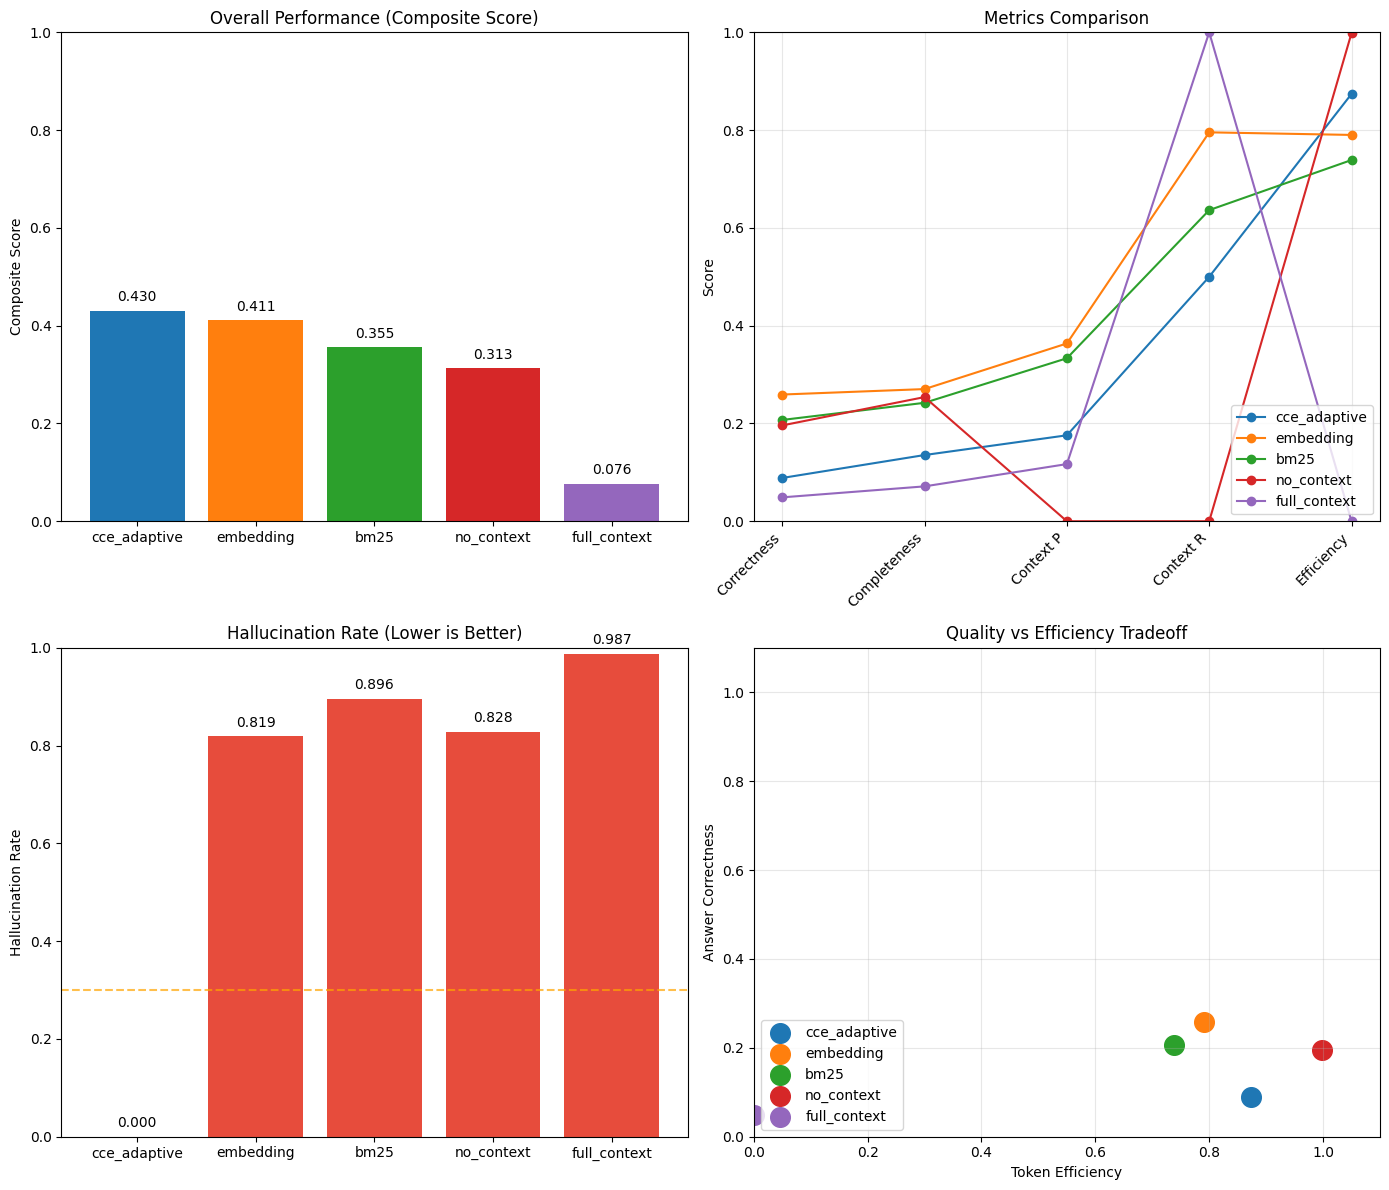

Saved: comprehensive_results.png


In [21]:
# Cell 20: Visualize comprehensive results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

methods_order = df_comparison['Method'].tolist()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 1. Composite scores
ax1 = axes[0, 0]
bars = ax1.bar(methods_order, df_comparison['Composite'], color=colors[:len(methods_order)])
ax1.set_ylabel('Composite Score')
ax1.set_title('Overall Performance (Composite Score)')
ax1.set_ylim(0, 1)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontsize=10)

# 2. Metric comparison radar-style
ax2 = axes[0, 1]
metric_cols = ['Correctness', 'Completeness', 'Context P', 'Context R', 'Efficiency']
for i, method in enumerate(methods_order):
    row = df_comparison[df_comparison['Method'] == method].iloc[0]
    values = [row[m] for m in metric_cols]
    ax2.plot(metric_cols, values, 'o-', label=method, color=colors[i % len(colors)])
ax2.set_ylabel('Score')
ax2.set_title('Metrics Comparison')
ax2.legend(loc='lower right')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Hallucination rate (lower is better)
ax3 = axes[1, 0]
halluc_values = df_comparison['Hallucination'].tolist()
bars3 = ax3.bar(methods_order, halluc_values, color=['#e74c3c' if v > 0.3 else '#2ecc71' for v in halluc_values])
ax3.set_ylabel('Hallucination Rate')
ax3.set_title('Hallucination Rate (Lower is Better)')
ax3.set_ylim(0, 1)
ax3.axhline(y=0.3, color='orange', linestyle='--', alpha=0.7, label='Threshold')
for bar in bars3:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontsize=10)

# 4. Efficiency vs Quality tradeoff
ax4 = axes[1, 1]
for i, method in enumerate(methods_order):
    row = df_comparison[df_comparison['Method'] == method].iloc[0]
    ax4.scatter(row['Efficiency'], row['Correctness'], s=200,
                color=colors[i % len(colors)], label=method)
ax4.set_xlabel('Token Efficiency')
ax4.set_ylabel('Answer Correctness')
ax4.set_title('Quality vs Efficiency Tradeoff')
ax4.legend(loc='lower left')
ax4.set_xlim(0, 1.1)
ax4.set_ylim(0, 1.1)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comprehensive_results.png', dpi=150)
plt.show()
print("Saved: comprehensive_results.png")

In [22]:
# Cell 21: Results by category
print("Results by Category")
print("="*70)

# Organize results by category
results_by_category = defaultdict(lambda: defaultdict(list))

for method, results in all_results.items():
    for r in results:
        cat = r.metadata.get('category', 'unknown')
        results_by_category[cat][method].append(r.get_composite_score())

# Create category comparison table
cat_data = []
for cat in Category:
    row = {'Category': cat.value}
    for method in ['no_context', 'bm25', 'embedding', 'full_context', 'cce_adaptive']:
        scores = results_by_category[cat.value].get(method, [])
        row[method] = np.mean(scores) if scores else 0.0
    cat_data.append(row)

df_category = pd.DataFrame(cat_data)
print(df_category.to_string(index=False, float_format='{:.3f}'.format))

Results by Category
      Category  no_context  bm25  embedding  full_context  cce_adaptive
  architecture       0.440 0.564      0.711         0.048         0.547
     api_usage       0.448 0.433      0.472         0.048         0.459
implementation       0.250 0.315      0.346         0.082         0.459
     debugging       0.235 0.238      0.289         0.100         0.383
 configuration       0.232 0.251      0.314         0.068         0.345
     data_flow       0.227 0.308      0.256         0.143         0.343


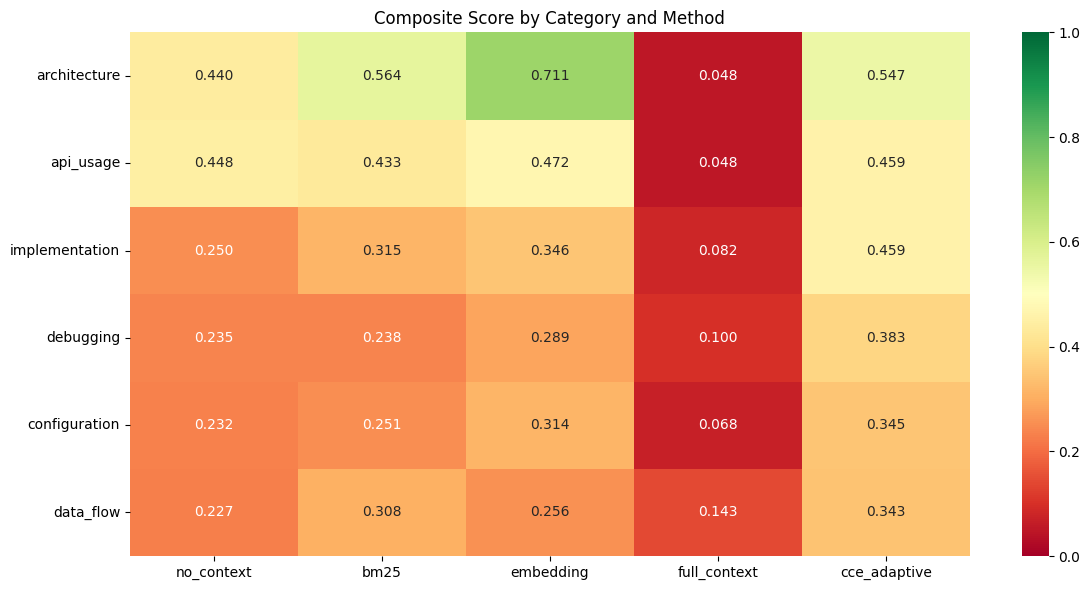

Saved: category_heatmap.png


In [23]:
# Cell 22: Category heatmap
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for heatmap
method_cols = [c for c in df_category.columns if c != 'Category']
heatmap_data = df_category[method_cols].values

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    xticklabels=method_cols,
    yticklabels=df_category['Category'],
    ax=ax,
    vmin=0,
    vmax=1,
)

ax.set_title('Composite Score by Category and Method')
plt.tight_layout()
plt.savefig('category_heatmap.png', dpi=150)
plt.show()
print("Saved: category_heatmap.png")

In [24]:
# Cell 23: Statistical significance testing
from scipy import stats

print("Statistical Significance Testing")
print("="*70)
print("\nComparing CCE Adaptive against baselines (paired t-test)")
print()

cce_scores = [r.get_composite_score() for r in all_results.get('cce_adaptive', [])]

if cce_scores:
    for method in ['no_context', 'bm25', 'embedding', 'full_context']:
        baseline_scores = [r.get_composite_score() for r in all_results.get(method, [])]

        if len(baseline_scores) == len(cce_scores):
            t_stat, p_value = stats.ttest_rel(cce_scores, baseline_scores)
            mean_diff = np.mean(cce_scores) - np.mean(baseline_scores)

            print(f"CCE vs {method}:")
            print(f"  Mean difference: {mean_diff:+.3f}")
            print(f"  t-statistic: {t_stat:.3f}")
            print(f"  p-value: {p_value:.4f}")
            print(f"  Significant (p<0.05): {'Yes' if p_value < 0.05 else 'No'}")
            print()
else:
    print("No CCE results available for comparison")

Statistical Significance Testing

Comparing CCE Adaptive against baselines (paired t-test)

CCE vs no_context:
  Mean difference: +0.117
  t-statistic: 4.157
  p-value: 0.0020
  Significant (p<0.05): Yes

CCE vs bm25:
  Mean difference: +0.074
  t-statistic: 1.682
  p-value: 0.1235
  Significant (p<0.05): No

CCE vs embedding:
  Mean difference: +0.019
  t-statistic: 0.560
  p-value: 0.5880
  Significant (p<0.05): No

CCE vs full_context:
  Mean difference: +0.354
  t-statistic: 11.098
  p-value: 0.0000
  Significant (p<0.05): Yes



In [25]:
# Cell 24: Summary
print("="*70)
print("WEEK 8 COMPREHENSIVE EVALUATION (v8 - PROBE METHOD)")
print("="*70)

print('''
PROBE-BASED CODE DETECTION (Week 3 Best: 93.5% accuracy)
============================================================

CRITICAL FIX in v8:
  Previous versions used raw_entropy which triggers on ANY uncertainty,
  including language words like "you", "also", "please".

  The PROBE method only triggers on CODE-specific uncertainty!

How the PROBE method works:
  1. For each top-10 candidate next token:
     - Build 2-token lookahead sequence
     - Extract hidden states from layers [16, 24, 31]
     - Classify as CODE or LANGUAGE using trained probe
     - Sum probability mass on CODE candidates → code_votes
  2. If code_votes > 0.06 → trigger retrieval

Why this is better:
  - raw_entropy: Triggers on "you", "also", "please" (language uncertainty)
  - PROBE: Only triggers on code-specific uncertainty
  - 93.5% accuracy at distinguishing code vs language generation

PROBE CONFIGURATION (from Week3_Improved_Methods.ipynb):
  uncertainty_method: probe
  uncertainty_threshold: 0.06
  probe_layers: [16, 24, 31]
  max_retrievals: 5
  cooldown_tokens: 15
''')

# Print best method
if not df_comparison.empty:
    best = df_comparison.iloc[0]
    print(f"BEST METHOD: {best['Method']}")
    print(f"  Composite Score: {best['Composite']:.3f}")
    print(f"  Correctness: {best['Correctness']:.3f}")
    print(f"  Efficiency: {best['Efficiency']:.3f}")

print("\nPROBE ADAPTIVE RETRIEVAL DETAILS:")
if 'cce_debug' in dir() and cce_debug:
    total_ret = sum(d['total_retrievals'] for d in cce_debug)
    avg_ret = total_ret / len(cce_debug)
    print(f"  Average retrievals per example: {avg_ret:.1f}")
    print(f"  File list overhead: {file_list_tokens} tokens")
    print(f"  Vector similarity threshold: {adaptive_gen.topic_inferrer.vector_similarity_threshold}")

    # Count unique files retrieved
    all_sources = []
    for d in cce_debug:
        all_sources.extend([s for s in d['context_sources'] if s not in ['query', 'initial']])
    unique_sources = set(all_sources)
    print(f"  Unique files retrieved: {len(unique_sources)}")

    # Count how many examples had matched files
    examples_with_matches = sum(1 for d in cce_debug if d.get('matched_files'))
    print(f"  Examples with token-based matches: {examples_with_matches}/{len(cce_debug)}")
    print()

    # Show retrieval details
    print("  Retrieval details:")
    for d in cce_debug:
        sources = [s for s in d['context_sources'] if s not in ['query', 'initial']]
        matched = d.get('matched_files', [])
        print(f"  {d['example_id']}: {d['total_retrievals']} retrievals")
        print(f"    Retrieved: {sources[:3]}{'...' if len(sources) > 3 else ''}")

WEEK 8 COMPREHENSIVE EVALUATION (v8 - PROBE METHOD)

PROBE-BASED CODE DETECTION (Week 3 Best: 93.5% accuracy)

CRITICAL FIX in v8:
  Previous versions used raw_entropy which triggers on ANY uncertainty,
  including language words like "you", "also", "please".
  
  The PROBE method only triggers on CODE-specific uncertainty!

How the PROBE method works:
  1. For each top-10 candidate next token:
     - Build 2-token lookahead sequence
     - Extract hidden states from layers [16, 24, 31]
     - Classify as CODE or LANGUAGE using trained probe
     - Sum probability mass on CODE candidates → code_votes
  2. If code_votes > 0.06 → trigger retrieval

Why this is better:
  - raw_entropy: Triggers on "you", "also", "please" (language uncertainty)
  - PROBE: Only triggers on code-specific uncertainty
  - 93.5% accuracy at distinguishing code vs language generation

PROBE CONFIGURATION (from Week3_Improved_Methods.ipynb):
  uncertainty_method: probe
  uncertainty_threshold: 0.06
  probe_layers

In [26]:
# Cell 25: Export results
results_export = {
    'version': 'v8_probe_method',
    'config': {
        'uncertainty_method': 'probe',
        'uncertainty_threshold': 0.06,
        'probe_layers': [16, 24, 31],
        'max_retrievals': 5,
        'cooldown_tokens': 15,
        'initial_context': 'file_list',
        'file_list_tokens': file_list_tokens,
        'retriever': 'EmbeddingRetriever',
        'file_matching_method': 'hybrid_query_token_filtering',
        'vector_similarity_threshold': 0.35,
        'embedder': 'all-MiniLM-L6-v2',
        'deduplication': True,
        'week3_accuracy': '93.5%',
    },
    'comparison_table': df_comparison.to_dict('records'),
    'category_results': df_category.to_dict('records'),
    'hallucination_tests': hallucination_results,
    'spike_detection_tests': spike_results,
    'cce_debug': cce_debug if 'cce_debug' in dir() else [],
}

with open('week8_results_v8_probe.json', 'w') as f:
    json.dump(results_export, f, indent=2, default=str)

print("Results exported to week8_results_v8_probe.json")

# Download files
try:
    from google.colab import files
    for fname in ['benchmark_distribution.png', 'hallucination_detection.png',
                  'spike_detection.png', 'comprehensive_results.png',
                  'category_heatmap.png', 'week8_results_v8_probe.json']:
        if os.path.exists(fname):
            files.download(fname)
except:
    print("Download files manually or run locally")

Results exported to week8_results_v8_probe.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>